#### Load Dependencies 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import yaml
import numpy as np
import os

In [3]:
### Check the current working directory
print(os.getcwd())

d:\Joseph\Projects\kg-default-of-credit-cards\notebooks


#### Load Data

In [4]:
# read csv file
df = pd.read_csv("../data/UCI_Credit_Card.csv")

### Explore Data

In [5]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
# Determine the data types of each column in the training data
print(df.info())
target_variable = 'default.payment.next.month'


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

#### From the results above, all of the variables are either float or int. There are no objects / binary data types.

In [ ]:
# Determine if there are any missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


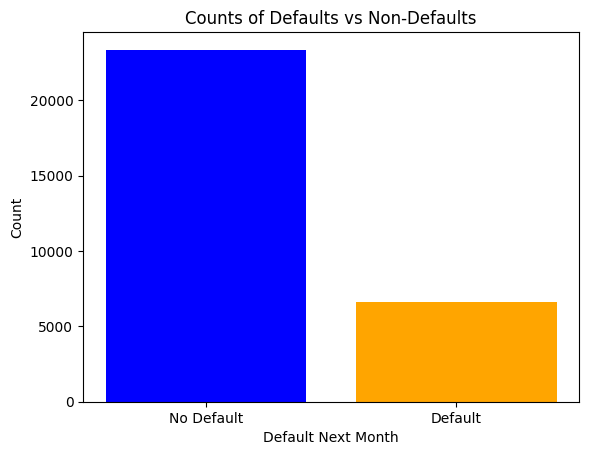

In [7]:
# Plot the distribution of the target variable 'default.payment.next.month'
plt.bar(
    df['default.payment.next.month'].value_counts().index, 
    df['default.payment.next.month'].value_counts().values, 
    color=['blue', 'orange']
)
plt.xticks([0,1], ['No Default','Default'])
plt.xlabel('Default Next Month')
plt.ylabel('Count')
plt.title('Counts of Defaults vs Non-Defaults')
plt.show()

In [ ]:
# Determine if there are any missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64


In [8]:
# Ratio of defaults to non-defaults
default_counts = df['default.payment.next.month'].value_counts()
default_ratio = default_counts[1] / default_counts[0]
print(f"Ratio of defaults to non-defaults: {default_ratio:.4f}")

# Ratio of defaults to total samples
default_ratio_total = default_counts[1] / len(df)
print(f"Ratio of defaults to total samples: {default_ratio_total:.4f}")

Ratio of defaults to non-defaults: 0.2840
Ratio of defaults to total samples: 0.2212


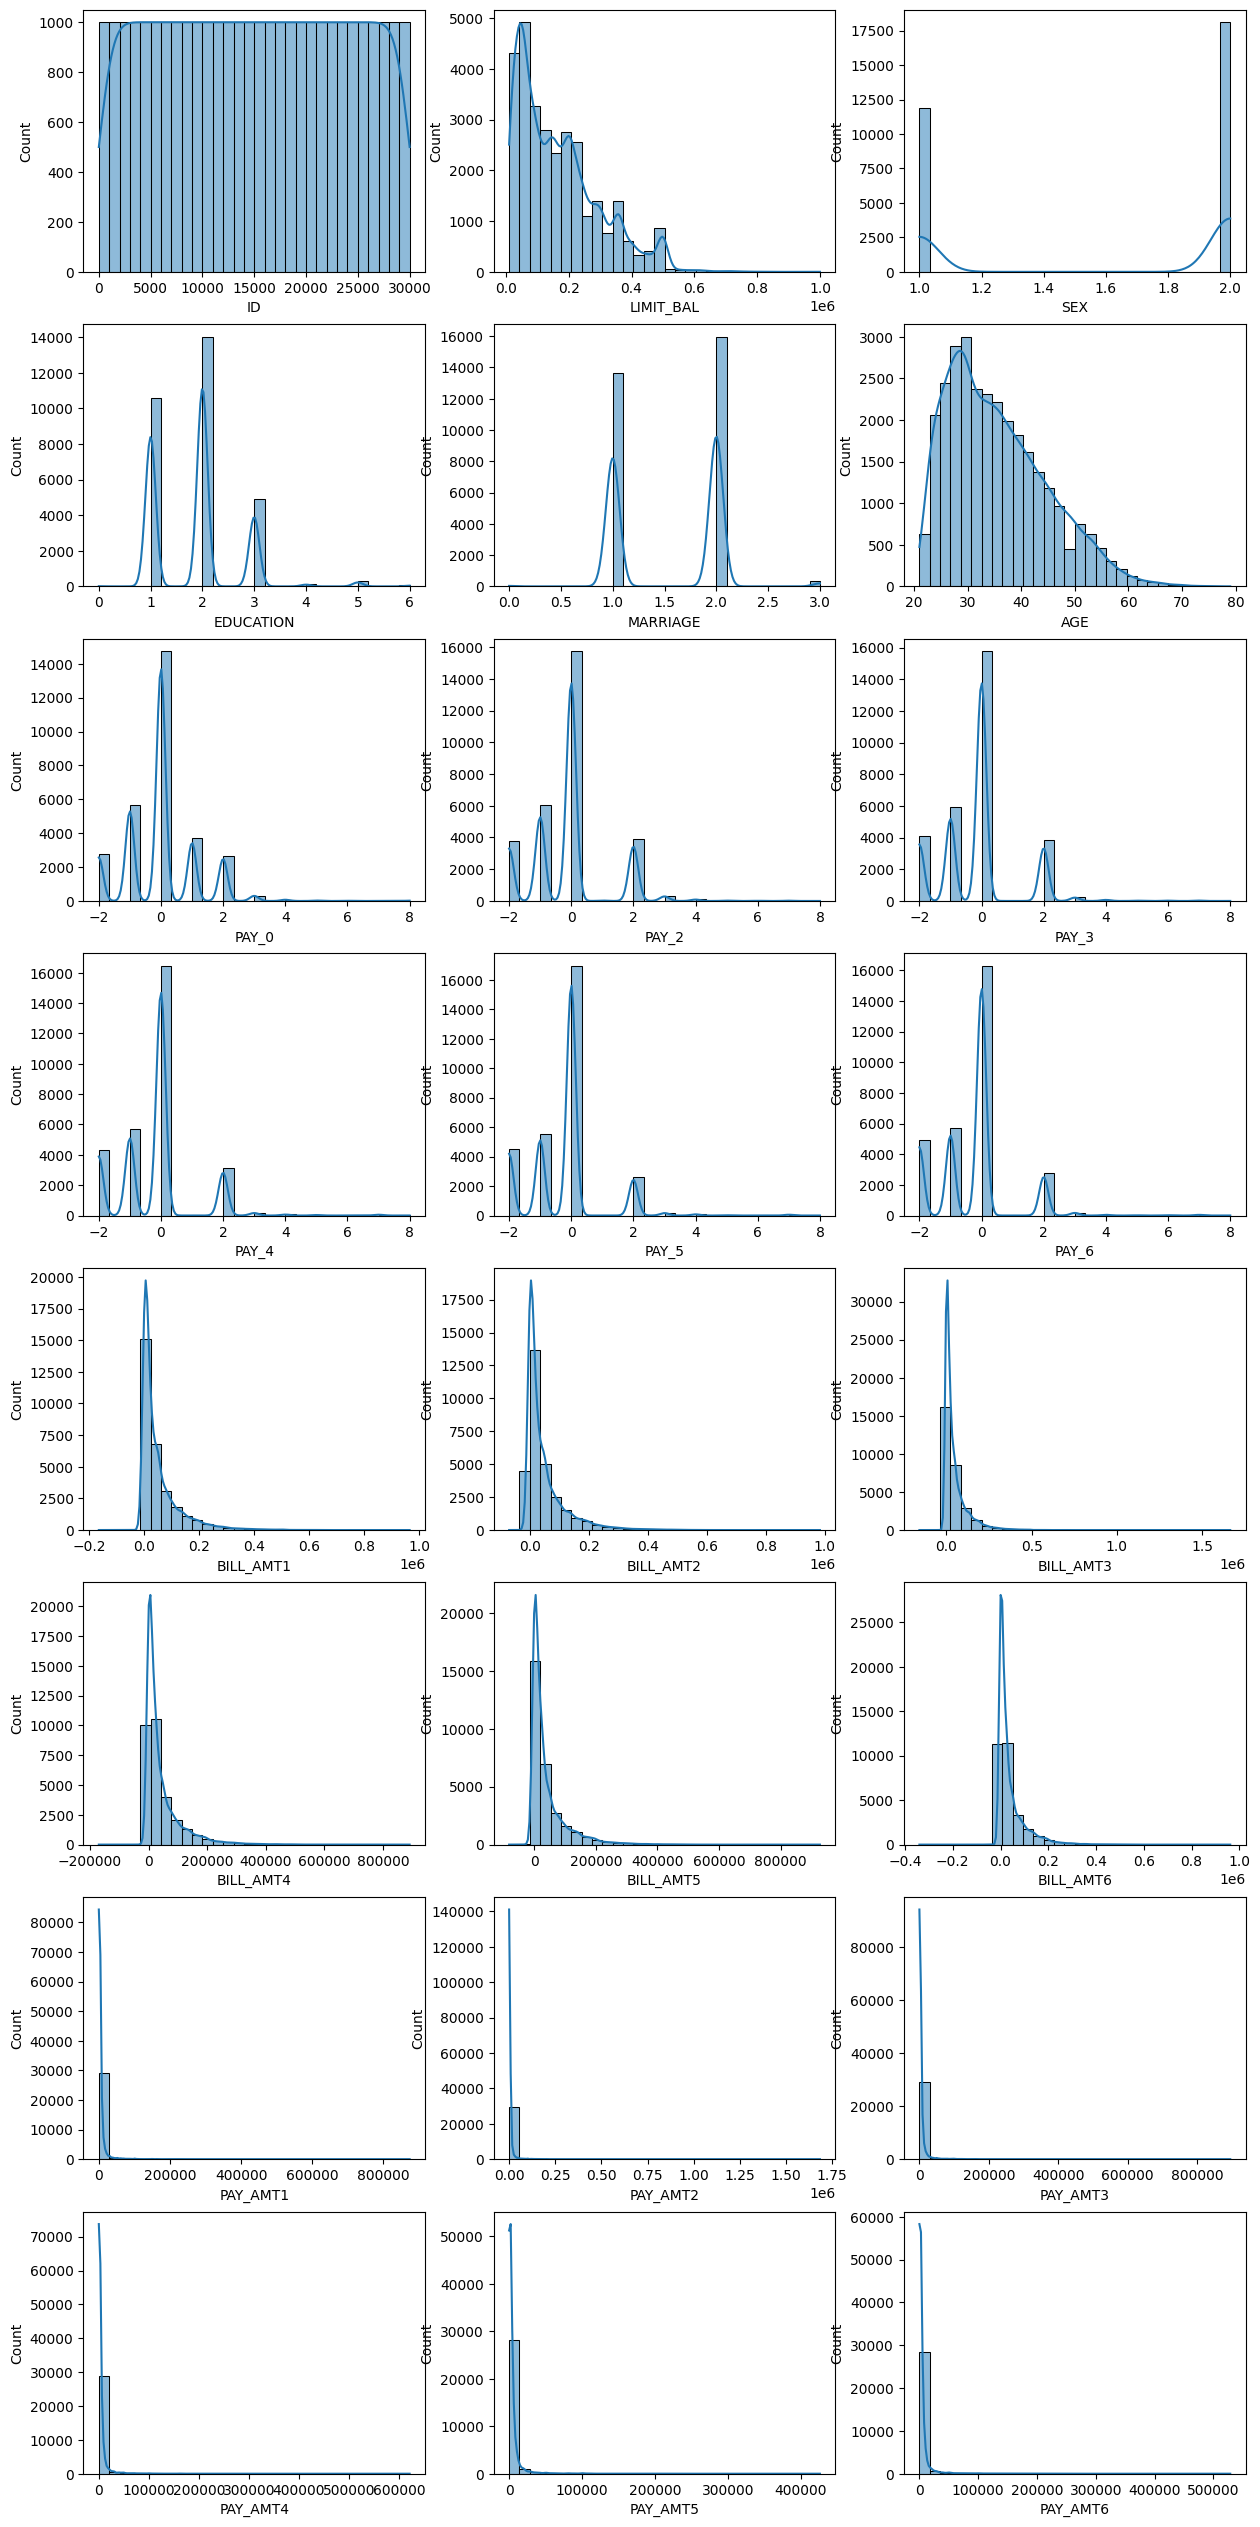

In [9]:
# Plot the distribution of the explanatory variables in 3 columns
explanatory_variables = [col for col in df.columns if col != target_variable]
num_explanatory = len(explanatory_variables)
num_cols = 3    
num_rows = (num_explanatory + num_cols - 1) // num_cols  # Calculate required rows
plt.figure(figsize=(15, num_rows * 4))  # Adjust height based on number of rows
for i, var in enumerate(explanatory_variables):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[var], kde=True, bins=30)


In [10]:
binary_variables = ["SEX", "MARRIAGE"]
ordinal_variables = ["EDUCATION", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
numeric_variables = [col for col in df.columns if (col not in binary_variables and col not in ordinal_variables and col != target_variable and col != 'ID')]
print("numeric_variables:", numeric_variables)

numeric_variables: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


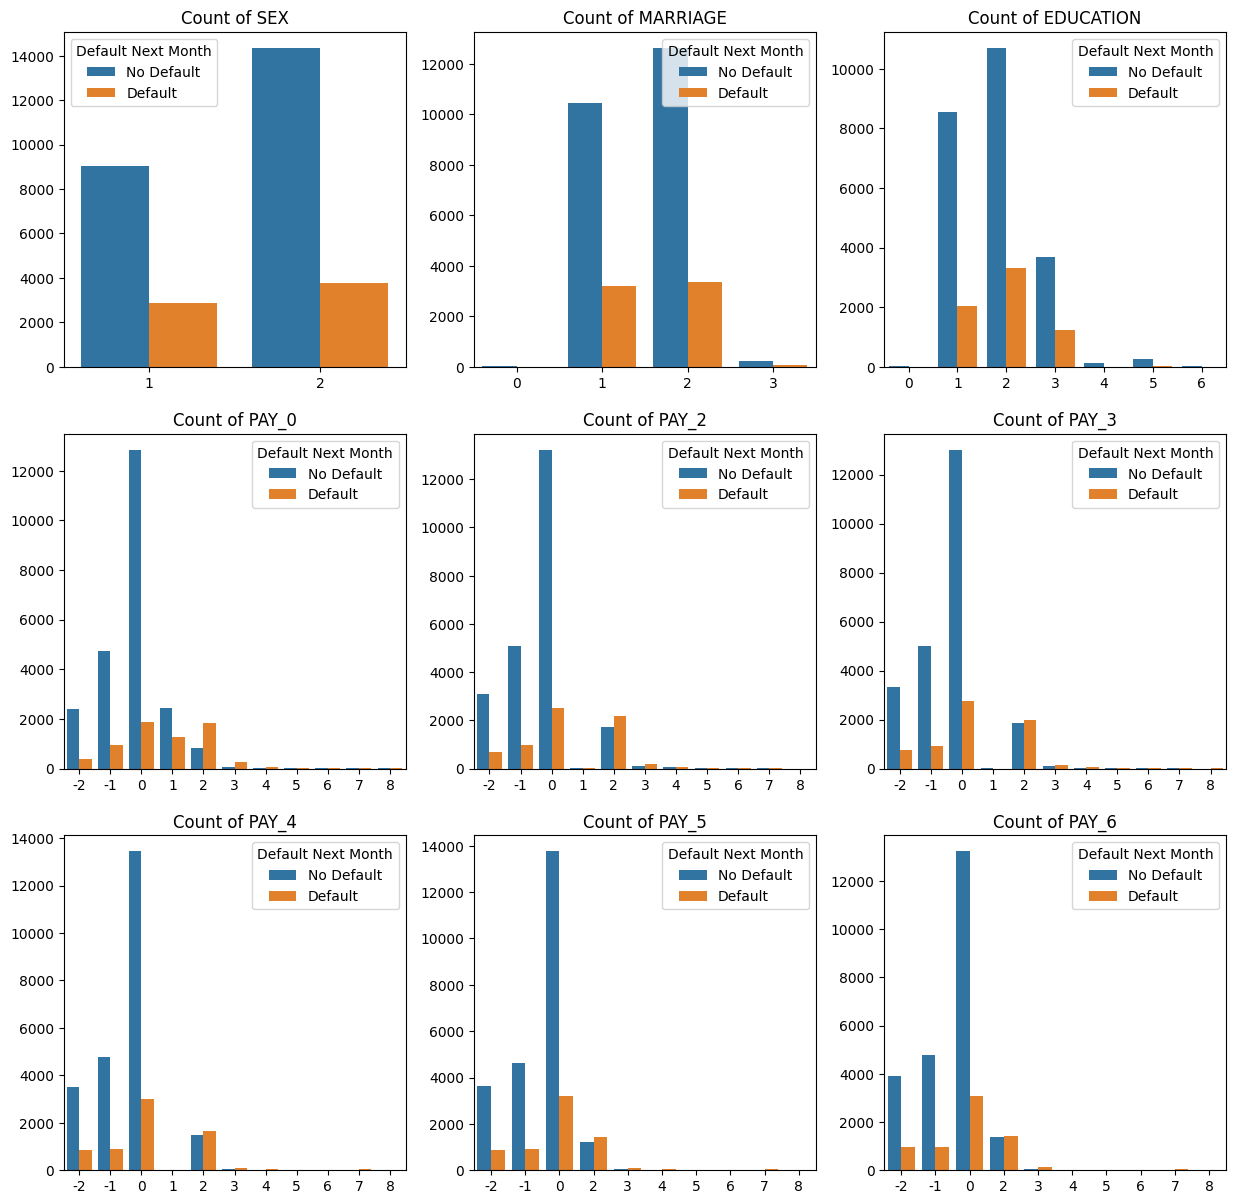

In [11]:
# Bar plot for binary variables and ordinal variables vs the target variable in 3 columns  
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(binary_variables + ordinal_variables):
    plt.subplot(4, 3, i + 1)
    sns.countplot(x=var, hue=target_variable, data=df)
    plt.title(f'Count of {var}')
    plt.xlabel("")
    plt.ylabel("")
    plt.legend(title='Default Next Month', labels=['No Default', 'Default'])    

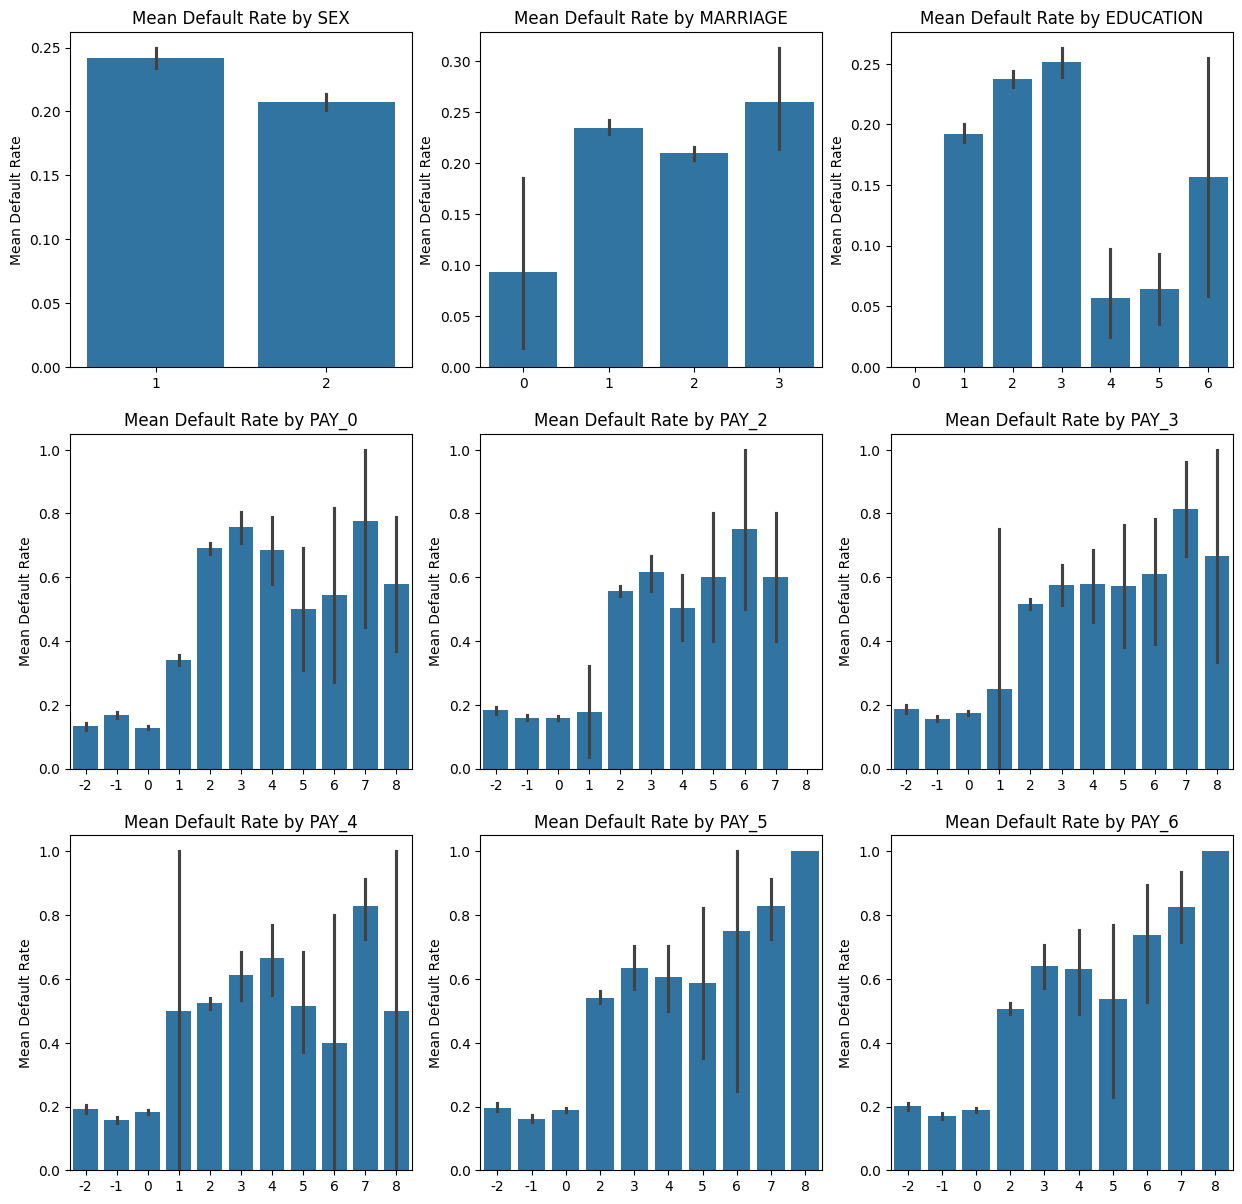

In [18]:
# For non-numeric variables, calculate the mean of the target variable for each category and plot a bar plot
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(binary_variables + ordinal_variables):
    plt.subplot(4, 3, i + 1)
    sns.barplot(x=var, y=target_variable, data=df)
    plt.title(f'Mean Default Rate by {var}')
    plt.xlabel("")
    plt.ylabel("Mean Default Rate")
    

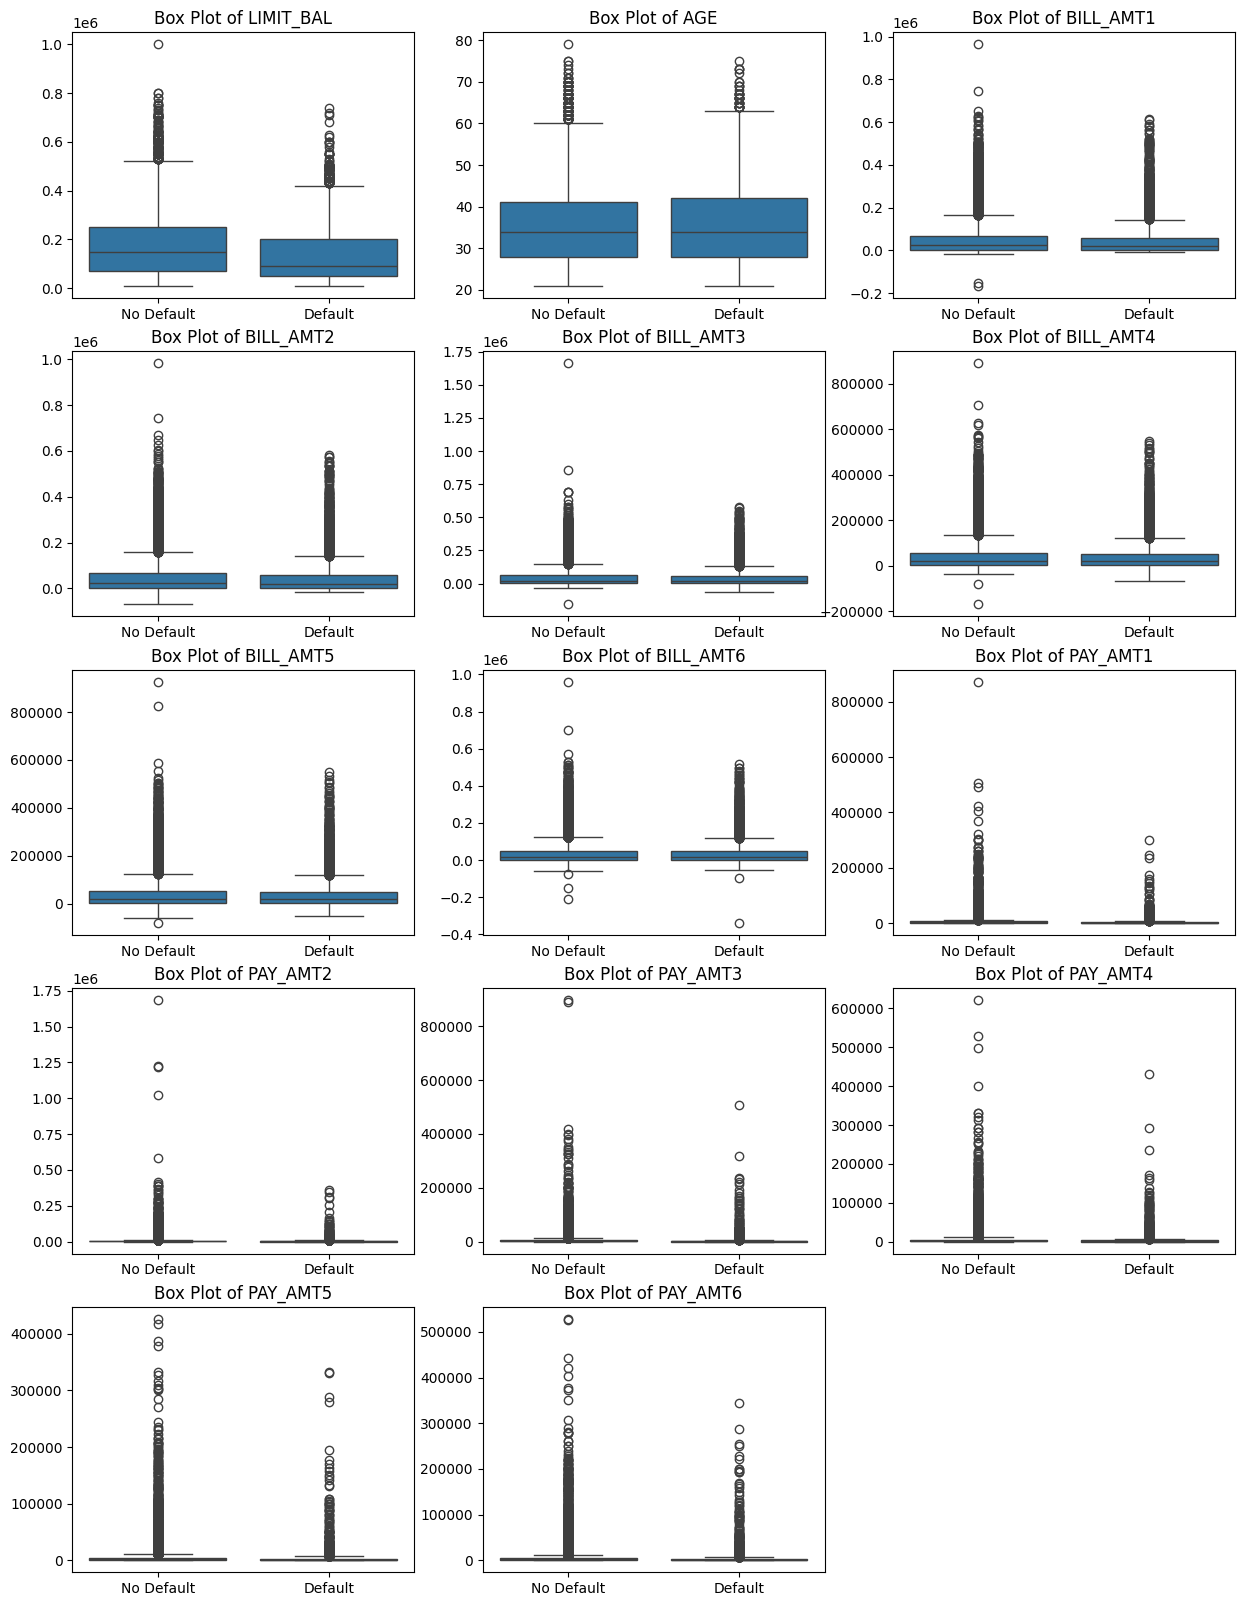

In [15]:
# Box plot for numeric variables vs the target variable in 3 columns
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(numeric_variables):
    plt.subplot(5, 3, i + 1)
    sns.boxplot(x=target_variable, y=var, data=df)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'Box Plot of {var}')
    plt.xticks([0,1], ['No Default','Default'])

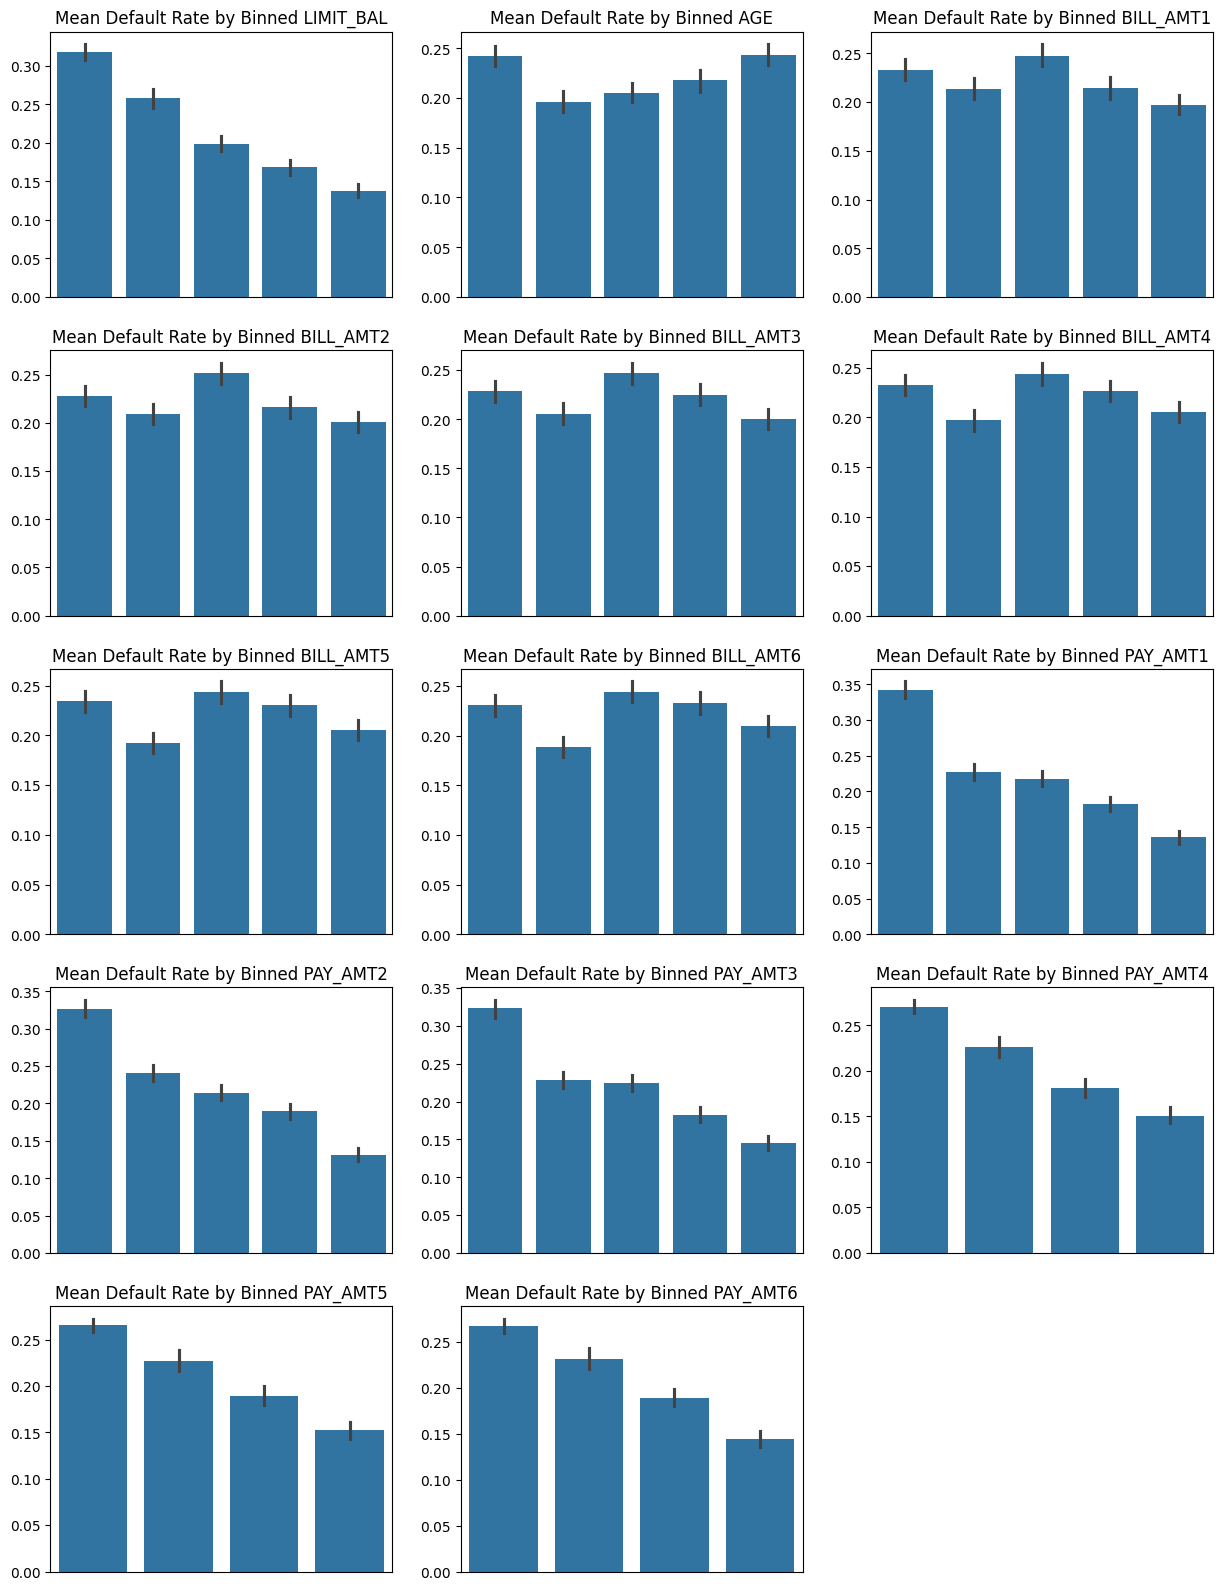

In [21]:
# Create barplots for each numeric variable against the target variable with at most 5 bins, using the maximum numeric variable on the x-axis
plt.figure(figsize=(15, 20))  # Adjust height based on number of rows
for i, var in enumerate(numeric_variables):
    plt.subplot(5, 3, i + 1)
    df[f'{var}_binned'] = pd.qcut(df[var], q=5, duplicates='drop')
    sns.barplot(x=f'{var}_binned', y=target_variable, data=df)
    plt.xlabel("")
    plt.ylabel("")
    plt.title(f'Mean Default Rate by Binned {var}')
    plt.xticks([])